In [1]:
import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve, auc, roc_auc_score,
    classification_report, confusion_matrix, f1_score
)

%matplotlib inline
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
# Load sparse feature matrices
X_train = scipy.sparse.load_npz('../data/X_train_v2.npz')
X_test  = scipy.sparse.load_npz('../data/X_test_v2.npz')

# Load labels
y_train = np.load('../data/y_train_v2.npy')
y_test  = np.load('../data/y_test_v2.npy')

print("X_train:", X_train.shape, "| type:", type(X_train).__name__)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape, "| frauds:", y_train.sum(), f"({y_train.mean()*100:.4f}%)")
print("y_test: ", y_test.shape, "| frauds:", y_test.sum(),  f"({y_test.mean()*100:.4f}%)")

X_train: (1037340, 77) | type: csr_matrix
X_test:  (259335, 77)
y_train: (1037340,) | frauds: 6005 (0.5789%)
y_test:  (259335,) | frauds: 1501 (0.5788%)


In [3]:
# Compute scale_pos_weight = (negatives / positives)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negatives: {neg:,}")
print(f"Positives: {pos:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negatives: 1,031,335
Positives: 6,005
scale_pos_weight: 171.75


In [4]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # imbalance handling
    eval_metric='aucpr',                # AUPRC as eval metric
    tree_method='hist',                 # fast, memory-efficient
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Training complete.")

Training complete.


In [5]:
# Get probabilities for fraud class
y_proba = model.predict_proba(X_test)[:, 1]

print("Probability stats:")
print(f"  Min:  {y_proba.min():.6f}")
print(f"  Max:  {y_proba.max():.6f}")
print(f"  Mean: {y_proba.mean():.6f}")
print()

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# AUPRC
auprc = auc(recall, precision)
roc   = roc_auc_score(y_test, y_proba)

print(f"AUPRC:   {auprc:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"Baseline AUPRC (fraud rate): {y_test.mean():.4f}")

Probability stats:
  Min:  0.000000
  Max:  0.999980
  Mean: 0.016604

AUPRC:   0.9475
ROC-AUC: 0.9991
Baseline AUPRC (fraud rate): 0.0058


In [6]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"  Precision: {precision[best_idx]:.4f}")
print(f"  Recall:    {recall[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

Best threshold (max F1): 0.9666
  Precision: 0.9524
  Recall:    0.8528
  F1:        0.8998


In [7]:
y_pred = (y_proba >= best_threshold).astype(int)

print(f"=== Threshold = {best_threshold:.4f} ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, digits=4))

=== Threshold = 0.9666 ===
Confusion Matrix:
[[257770     64]
 [   221   1280]]

              precision    recall  f1-score   support

           0     0.9991    0.9998    0.9994    257834
           1     0.9524    0.8528    0.8998      1501

    accuracy                         0.9989    259335
   macro avg     0.9758    0.9263    0.9496    259335
weighted avg     0.9989    0.9989    0.9989    259335



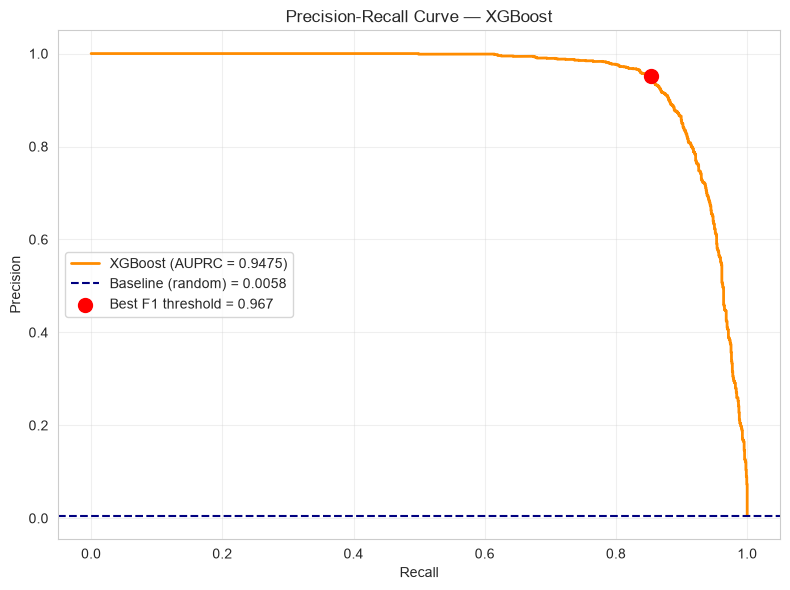

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'XGBoost (AUPRC = {auprc:.4f})')
plt.axhline(y=y_test.mean(), color='navy', linestyle='--',
            label=f'Baseline (random) = {y_test.mean():.4f}')
plt.scatter(recall[best_idx], precision[best_idx], color='red', s=100,
            zorder=5, label=f'Best F1 threshold = {best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Get feature names from the preprocessor
preprocessor = joblib.load('../models/preprocessor_v2.pkl')

# Extract feature names
num_features = preprocessor.transformers_[0][2]
cat_pipeline = preprocessor.transformers_[1][1]
onehot = cat_pipeline.named_steps['onehot']
cat_features = onehot.get_feature_names_out(preprocessor.transformers_[1][2])

feature_names = list(num_features) + list(cat_features)
print(f"Total features: {len(feature_names)}")
print(f"Model feature count: {model.feature_importances_.shape[0]}")

Total features: 77
Model feature count: 77


In [10]:
configs = [
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1},
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1},
    {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05},
    {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05},
    {'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.03},
]

results = []
for cfg in configs:
    m = XGBClassifier(
        **cfg,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train, y_train, verbose=False)
    proba = m.predict_proba(X_test)[:, 1]
    p, r, t = precision_recall_curve(y_test, proba)
    auprc = auc(r, p)
    f1 = 2 * (p * r) / (p + r + 1e-10)
    best_i = np.argmax(f1[:-1])
    
    results.append({
        **cfg,
        'AUPRC': round(auprc, 4),
        'Best_F1': round(f1[best_i], 4),
        'Best_Threshold': round(t[best_i], 4),
        'Precision': round(p[best_i], 4),
        'Recall': round(r[best_i], 4)
    })
    print(f"Done: {cfg} → AUPRC={auprc:.4f}")

df_results = pd.DataFrame(results).sort_values('AUPRC', ascending=False)
print("\n=== Results ===")
print(df_results.to_string(index=False))

Done: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1} → AUPRC=0.8754
Done: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1} → AUPRC=0.9475
Done: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05} → AUPRC=0.9459
Done: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05} → AUPRC=0.9592
Done: {'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.03} → AUPRC=0.8868

=== Results ===
 n_estimators  max_depth  learning_rate  AUPRC  Best_F1  Best_Threshold  Precision  Recall
          500          8           0.05 0.9592   0.9152          0.9385     0.9564  0.8774
          300          6           0.10 0.9475   0.8998          0.9666     0.9524  0.8528
          500          6           0.05 0.9459   0.8978          0.9622     0.9383  0.8608
          700          4           0.03 0.8868   0.8297          0.9670     0.8751  0.7888
          200          4           0.10 0.8754   0.8164          0.9672     0.8555  0.7808


In [11]:
# Pick the best configuration from Cell 10 (hardcode the winner)
best_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train, verbose=False)

# Recompute metrics on best model
y_proba = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
auprc = auc(recall, precision)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

y_pred = (y_proba >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Save bundle
bundle = {
    'model': best_model,
    'preprocessor': preprocessor,
    'threshold': float(best_threshold),
    'auprc': float(auprc),
    'metrics': {
        'AUPRC': round(auprc, 4),
        'Precision': round(tp / (tp + fp), 4),
        'Recall': round(tp / (tp + fn), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'True Positives': int(tp),
        'False Positives': int(fp),
        'False Negatives': int(fn),
        'True Negatives': int(tn)
    }
}

joblib.dump(bundle, '../models/fraud_model_xgb_bundle.pkl')
print("Bundle saved: models/fraud_model_xgb_bundle.pkl")
print()
print("Metrics:", bundle['metrics'])

Bundle saved: models/fraud_model_xgb_bundle.pkl

Metrics: {'AUPRC': 0.9459, 'Precision': np.float64(0.9383), 'Recall': np.float64(0.8608), 'F1': 0.8978, 'True Positives': 1292, 'False Positives': 85, 'False Negatives': 209, 'True Negatives': 257749}


                     Model  AUPRC  Precision  Recall     F1
         SGD (PCA dataset) 0.7196     0.7900  0.8061 0.7980
    SGD (readable dataset) 0.0908     0.1417  0.4744 0.2182
XGBoost (readable dataset) 0.9459     0.9383  0.8608 0.8978


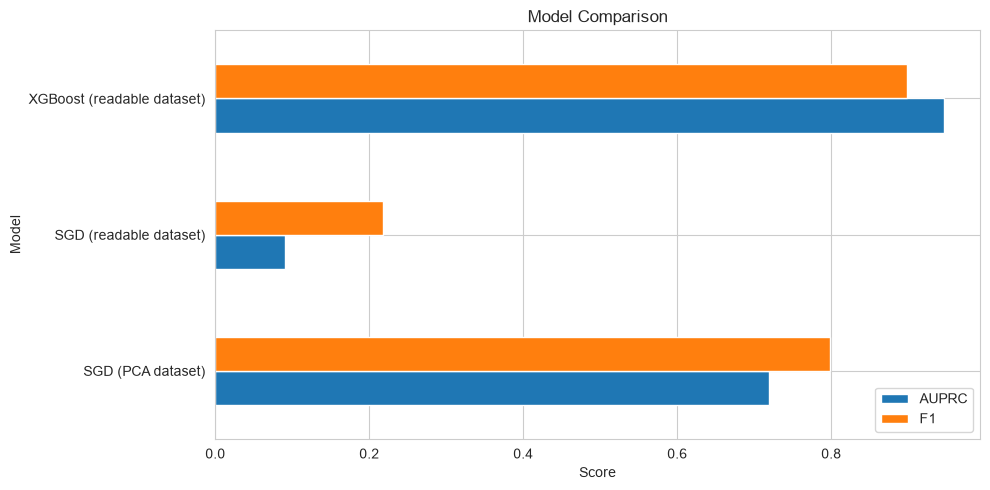

In [12]:
comparison = pd.DataFrame([
    {'Model': 'SGD (PCA dataset)', 'AUPRC': 0.7196, 'Precision': 0.79, 'Recall': 0.8061, 'F1': 0.798},
    {'Model': 'SGD (readable dataset)', 'AUPRC': 0.0908, 'Precision': 0.1417, 'Recall': 0.4744, 'F1': 0.2182},
    {'Model': 'XGBoost (readable dataset)', 
     'AUPRC': bundle['metrics']['AUPRC'],
     'Precision': bundle['metrics']['Precision'],
     'Recall': bundle['metrics']['Recall'],
     'F1': bundle['metrics']['F1']}
])
print(comparison.to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
comparison.set_index('Model')[['AUPRC', 'F1']].plot(kind='barh', ax=plt.gca())
plt.title('Model Comparison')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

In [13]:
print("=== PROBABILITY DISTRIBUTION ===")
for p in [50, 90, 99, 99.9, 99.99]:
    print(f"  {p}%: {np.percentile(y_proba, p):.6f}")

print()
print("Count > 0.5:  ", (y_proba > 0.5).sum())
print("Count > 0.3:  ", (y_proba > 0.3).sum())
print("Count > 0.1:  ", (y_proba > 0.1).sum())
print("Count > best_threshold: ", (y_proba > best_threshold).sum())

=== PROBABILITY DISTRIBUTION ===
  50%: 0.000506
  90%: 0.012240
  99%: 0.667964
  99.9%: 0.999629
  99.99%: 0.999885

Count > 0.5:   3264
Count > 0.3:   4685
Count > 0.1:   8872
Count > best_threshold:  1376
